# Uber Trips Analysis

The goal is to describe when and where Uber pickups happen in New York City. The data has 1,028,136 pickups of September 2014, each with the time, the latitude and the longitude of the pickup and the code of the Uber base that dispatched it (`uber-raw-data-sep14.csv`).

Reference solution: [Uber Trips Analysis using Python](https://amanxai.com/2021/04/21/uber-trips-analysis-using-python/) (Aman Kharwal). Dataset: the FiveThirtyEight [uber-tlc-foil-response](https://github.com/fivethirtyeight/uber-tlc-foil-response) repository, file `uber-trip-data/uber-raw-data-sep14.csv` (the copy the reference links to is no longer available).

The reference draws density plots (`distplot`) of the day of the month, the weekday and the hour, and concludes that Monday is the most profitable day, that fewer people use Uber on Saturdays and that 6 pm is the busiest hour. The weekday numbering used for these conclusions is checked here against the calendar, and the counts are compared per day instead of in total.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Data Visualization/uber_trips_analysis')

## Data Loading

In [2]:
data = pd.read_csv("uber-raw-data-sep14.csv")
data["Date/Time"] = pd.to_datetime(data["Date/Time"], format="%m/%d/%Y %H:%M:%S")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   Date/Time  1028136 non-null  datetime64[us]
 1   Lat        1028136 non-null  float64       
 2   Lon        1028136 non-null  float64       
 3   Base       1028136 non-null  str           
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 37.3 MB


## Data Cleaning

There are no null values. 24,037 rows are exact duplicates (same minute, same coordinates, same base), but the coordinates are rounded to four decimals and several pickups in the same minute at the same corner are plausible, so they are kept as separate pickups. Some pickups are far from New York City (the latitude goes from 39.99 to 41.35), probably bad GPS positions or trips that start in the suburbs. They are kept in the counts by day and by hour, and left out of the map, which is limited to the city.

In [3]:
print("null values:", data.isnull().sum().sum(), "| duplicated rows:", data.duplicated().sum())

inside_city = data["Lat"].between(40.55, 40.95) & data["Lon"].between(-74.15, -73.65)
print("pickups outside the map area:", (~inside_city).sum(), f"({(~inside_city).mean():.2%})")

null values: 0 | duplicated rows: 24037
pickups outside the map area: 14811 (1.44%)


## Feature Engineering

The day of the month, the weekday and the hour are taken from the date. `dt.weekday` numbers the days from **0 = Monday** to 6 = Sunday, and the name of the day is added so that the numbers are not misread.

In [4]:
data["day"] = data["Date/Time"].dt.day
data["weekday"] = data["Date/Time"].dt.weekday
data["weekday_name"] = data["Date/Time"].dt.day_name()
data["hour"] = data["Date/Time"].dt.hour

data[["Date/Time", "day", "weekday", "weekday_name", "hour"]].head(3)

,Date/Time,day,weekday,weekday_name,hour
0,2014-09-01 00:01:00,1,0,Monday,0
1,2014-09-01 00:01:00,1,0,Monday,0
2,2014-09-01 00:03:00,1,0,Monday,0


## Reference Reproduction

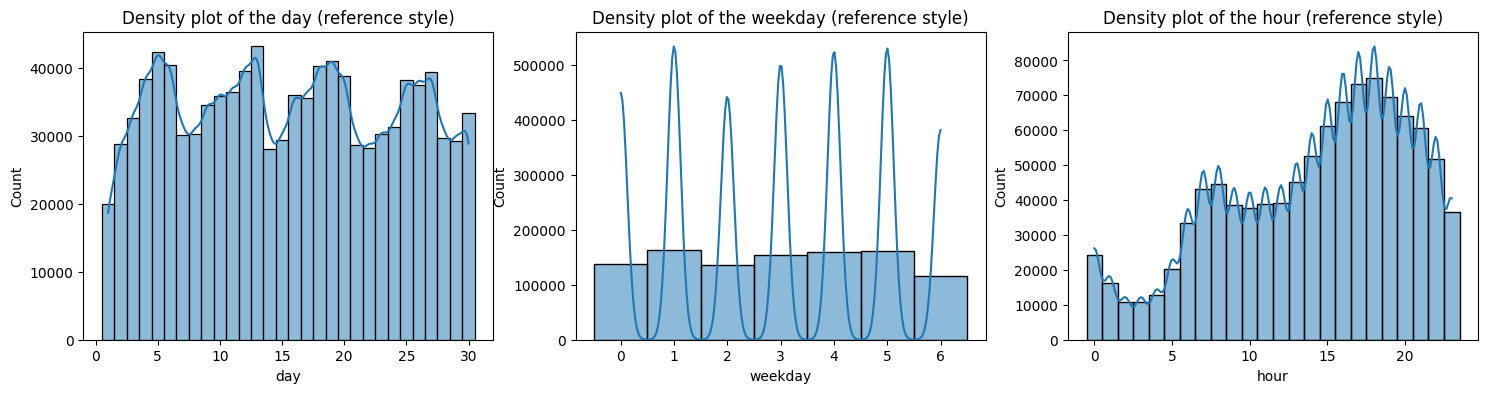

,day,weekday,weekday_name
0,1,0,Monday
638,2,1,Tuesday
1826,3,2,Wednesday


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, ["day", "weekday", "hour"]):
    sns.histplot(data[column], kde=True, ax=ax, discrete=True)
    ax.set_title(f"Density plot of the {column} (reference style)")
plt.show()

data.drop_duplicates("day")[["day", "weekday", "weekday_name"]].head(3)

The table shows that 1 September 2014 (a Monday) has the weekday value 0: the numbering starts with **0 = Monday** and ends with 6 = Sunday. The reference says that "0 indicates Sunday" and reads its plots from there, so all of its weekday conclusions are shifted by one day: what it calls Sunday is Monday, its "Monday" is Tuesday and its "Saturday" is Sunday. Its density plots also draw a smooth curve through values that are whole numbers (days 1 to 30, hours 0 to 23), which suggests values between the integers; a bar for each value is the right form.

## Pickups by Day of the Month

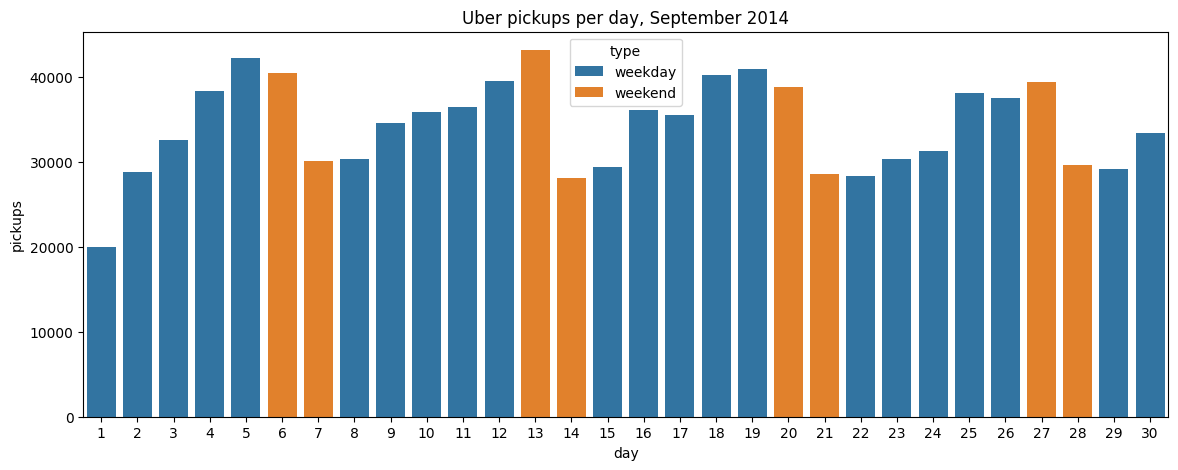

,day,weekday_name,pickups,type
0,1,Monday,19961,weekday
13,14,Sunday,28122,weekend
4,5,Friday,42319,weekday
12,13,Saturday,43205,weekend


In [6]:
per_day = data.groupby(["day", "weekday_name"]).size().reset_index(name="pickups")
per_day["type"] = np.where(per_day["weekday_name"].isin(["Saturday", "Sunday"]), "weekend", "weekday")

plt.figure(figsize=(14, 5))
sns.barplot(x="day", y="pickups", hue="type", data=per_day, dodge=False)
plt.title("Uber pickups per day, September 2014")
plt.show()
per_day.sort_values("pickups").iloc[[0, 1, -2, -1]]

The number of pickups follows a weekly rhythm. The busiest days are Saturday 13 September (43,205 pickups) and Friday 5 September (42,319); the quietest day is Monday 1 September (19,961), which was Labor Day, a public holiday, and the quietest Sunday is the 14th (28,122).

## Pickups by Day of the Week

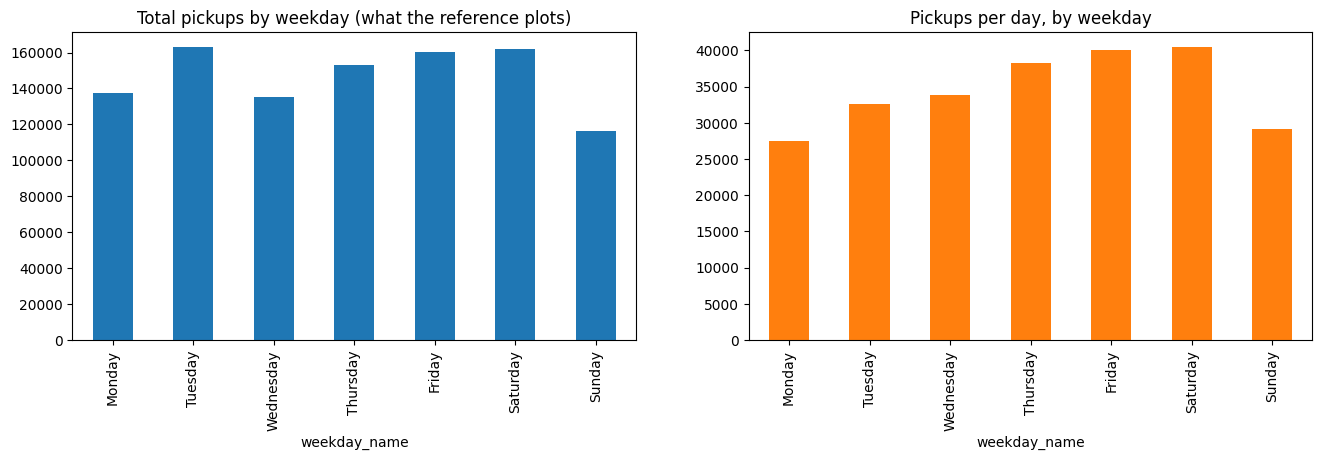

,total pickups,days in the month,pickups per day
weekday_name,,,
Monday,137288,5,27458.0
Tuesday,163230,5,32646.0
Wednesday,135373,4,33843.0
Thursday,153276,4,38319.0
Friday,160380,4,40095.0
Saturday,162057,4,40514.0
Sunday,116532,4,29133.0


In [7]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_table = data.groupby("weekday_name").size().reindex(order).to_frame("total pickups")
weekday_table["days in the month"] = data.groupby("weekday_name")["day"].nunique().reindex(order)
weekday_table["pickups per day"] = (weekday_table["total pickups"] / weekday_table["days in the month"]).round(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
weekday_table["total pickups"].plot(kind="bar", ax=axes[0], title="Total pickups by weekday (what the reference plots)")
weekday_table["pickups per day"].plot(kind="bar", ax=axes[1], color="tab:orange", title="Pickups per day, by weekday")
plt.show()
weekday_table

The total number of pickups by weekday (left) is misleading, because September 2014 has five Mondays and five Tuesdays and only four of each other day: Mondays and Tuesdays get a fifth more pickups just by occurring more often. Per day (right), the order is different: Saturday (40,514) and Friday (40,095) are the busiest days, then Thursday (38,319), while Monday is the quietest (27,458, with the holiday on 1 September included) followed by Sunday (29,133). The conclusions of the reference are therefore not supported by the data: Monday is not the most profitable day, and Saturday is not a day with fewer trips, it is the busiest.

## Pickups by Hour

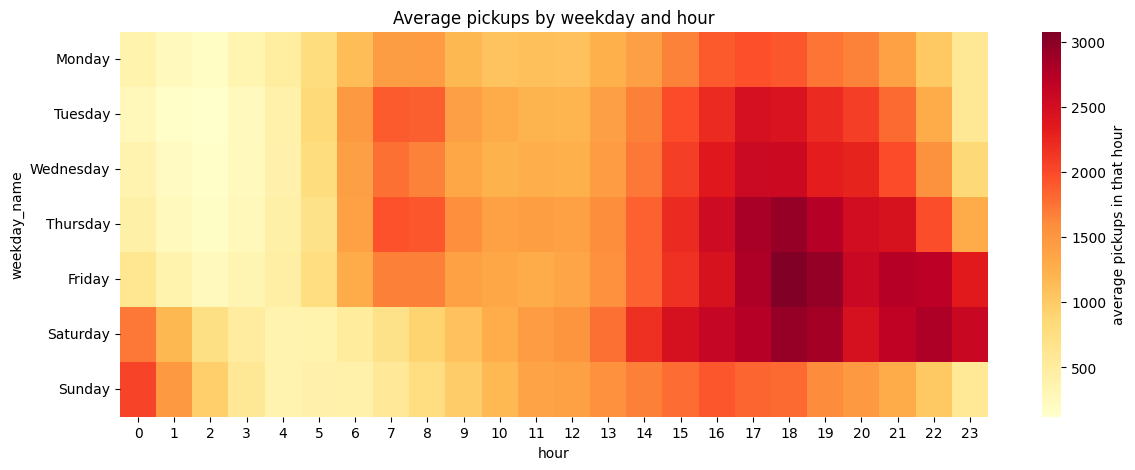

hour
18    75040
17    73373
19    69660
dtype: int64

In [8]:
hour_by_weekday = data.groupby(["weekday_name", "hour"]).size().unstack().reindex(order)
hour_by_weekday = hour_by_weekday.div(weekday_table["days in the month"], axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(hour_by_weekday, cmap="YlOrRd", cbar_kws={"label": "average pickups in that hour"})
plt.title("Average pickups by weekday and hour")
plt.show()

data.groupby("hour").size().sort_values(ascending=False).head(3)

The busiest hour of the month is 6 pm (75,040 pickups), followed by 5 pm (73,373) and 7 pm (69,660), which agrees with the reference. The heatmap adds what the single density plot hides. On weekdays there is a small morning peak around 7 and 8 am and a large evening peak from 5 to 7 pm; the evening peak is highest on Thursday and Friday. On Friday and Saturday the activity stays high until midnight and continues after it (the pickups of the early hours of Saturday and Sunday are those of the Friday and Saturday nights), while Sunday evening is quiet. The night is calm from 2 to 5 am on all days except after the weekend nights, and the morning rise starts around 5 to 6 am.

## Where the Pickups Happen

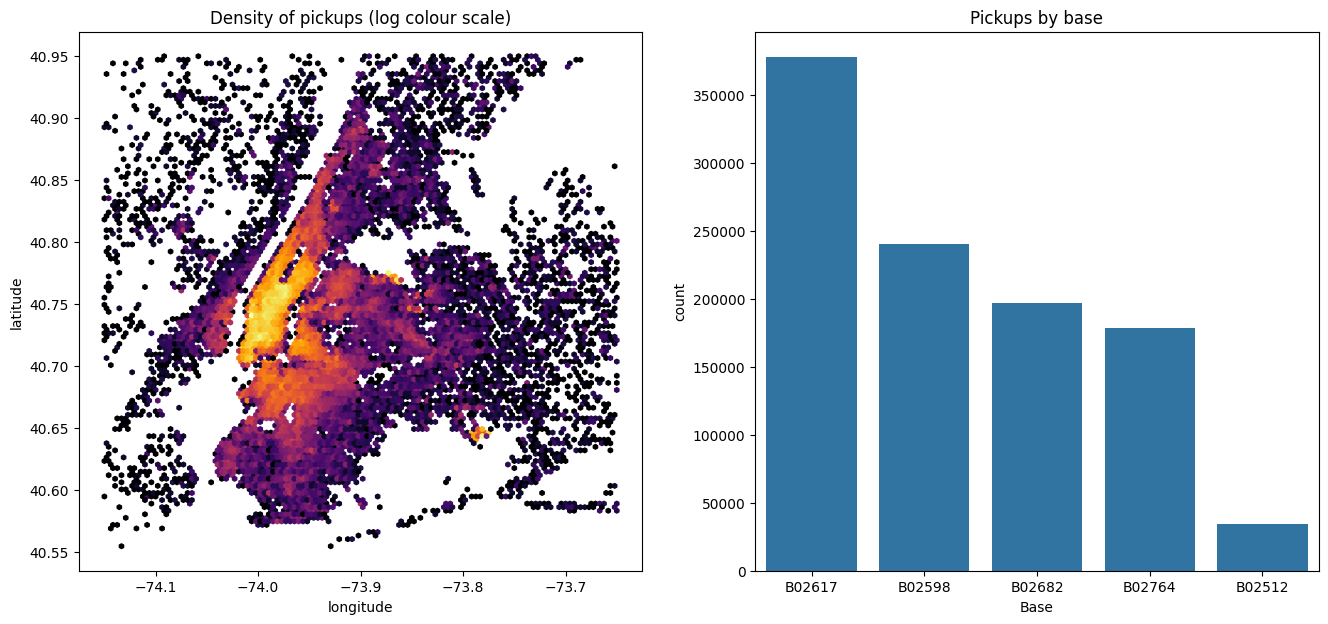

Base
B02617    36.7
B02598    23.4
B02682    19.2
B02764    17.3
B02512     3.3
Name: proportion, dtype: float64

In [9]:
city = data[inside_city]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].hexbin(city["Lon"], city["Lat"], gridsize=120, cmap="inferno", bins="log")
axes[0].set_title("Density of pickups (log colour scale)")
sns.countplot(x="Base", data=data, order=data["Base"].value_counts().index, ax=axes[1])
axes[1].set_title("Pickups by base")
for ax in axes: ax.set_xlabel(ax.get_xlabel() or "longitude")
axes[0].set_ylabel("latitude")
plt.show()

(data["Base"].value_counts(normalize=True) * 100).round(1)

The density map (each hexagon is coloured by the logarithm of the number of pickups inside it) shows that most pickups are in Manhattan, as the reference says, where the pickups form a dense band along the island. Brooklyn and western Queens have a lower but still clear density, and there is an isolated hot spot at about (-73.78, 40.645), where the airport JFK is located. The outer boroughs and the suburbs have only scattered pickups. The bases are unequal: B02617 dispatches 36.7% of the pickups, B02598 23.4%, B02682 19.2%, B02764 17.3% and B02512 only 3.3%; the base is the company that dispatched the trip, not the place of the pickup.

## Conclusion

**Reference approach.** The reference plots density curves of the day, the weekday and the hour of the 1,028,136 pickups of September 2014 and a map of the locations, and draws five conclusions: Monday is the most profitable day, fewer people use Uber on Saturdays, 6 pm is the busiest hour, the trips rise from about 5 am, and most pickups are near Manhattan.

**Check of the reference.** Two of the five conclusions do not hold. The weekday numbers of `dt.weekday` start with 0 = Monday (1 September 2014 was a Monday and has the value 0), but the reference reads 0 as Sunday, which shifts every weekday conclusion by one day. In addition, the total by weekday is inflated for Monday and Tuesday because September 2014 has five of each, so the counts have to be compared per day.

| Day | Pickups per day |
|---|---|
| Saturday | 40,514 |
| Friday | 40,095 |
| Thursday | 38,319 |
| Wednesday | 33,843 |
| Tuesday | 32,646 |
| Sunday | 29,133 |
| Monday | 27,458 (includes the Labor Day holiday) |

Saturday and Friday are the busiest days, and Monday and Sunday the quietest. The two other conclusions are confirmed and refined: 6 pm is the busiest hour (75,040 pickups), with a smaller morning peak on weekdays, and on Friday and Saturday nights the activity continues past midnight; the map confirms the concentration in Manhattan and shows a hot spot at JFK airport.

**Limitations.** One month of data (September 2014, including a public holiday and no comparison with other months) cannot show seasonal patterns. The data has no fare, trip length or driver, so nothing can be said about "profit". 24,037 exact duplicate rows were kept as separate pickups, and 1.4% of the pickups lie outside the map area (bad GPS positions or suburbs) and are counted in the totals but not shown on the map. The dataset covers the Uber pickups only, not the other taxi services.